## Wash count drivers — snapshot analysis (145 no-chem sites)

**Sections:**
1. **Snapshot** — n, target ranges, multi/single split, variance decomposition + USA map (region halo + localisation dots).
2. **Correlation matrices — global · region · localisation** — same top features, three side-by-side heatmaps at three geographic scopes. Bootstrap CIs on the global view flag noise.
3. **SHAP feature importance** — multivariate, non-linear, model-aware view per target.

In [1]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
import shap

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
df = pd.read_csv('../hypothesis-testing/_no_chem_data/sitewise-report.csv')

# Targets
retail     = df['2024_wash_count_retail']     + df['2025_wash_count_retail']
membership = df['2024_wash_count_membership'] + df['2025_wash_count_membership']
wash_total = retail + membership
targets = pd.DataFrame({'retail': retail, 'membership': membership, 'wash_total': wash_total})

# Feature engineering
def coerce(s):
    if pd.isna(s): return np.nan
    if isinstance(s, (int, float, np.integer, np.floating)): return float(s)
    c = re.sub(r'[\$,%\s]', '', str(s))
    if c in ('', '-', 'nan', 'NaN'): return np.nan
    try:    return float(c)
    except: return np.nan

TARGETS = ['2024_wash_count_retail','2024_wash_count_membership',
           '2025_wash_count_retail','2025_wash_count_membership']

# Geographic-identity columns. These describe WHERE the site is, not its 3-mile environment.
# They get excluded from X — but localisation + region are kept as grouping variables for analysis.
GEO_IDENTITY = ['latitude','longitude','region','state','city','zip',
                'dbscan_cluster_12km','dbscan_cluster_18km']
ID_COLS  = ['client_id_location_id','Address','client_id','Unnamed: 5','client_type']
DUP_COLS = ['Median Household Income.1','Average Household Income.1']
TEXT_COLS = [c for c in df.columns if any(k in c for k in ['-Name','-Website','-Chain Name'])]
CATEG = [c for c in df.columns if 'Competitor Type' in c or 'Car Wash Type' in c]

# Grouping variables kept separately for per-region / per-cluster analysis
loc_col    = df['localisation'].copy()
region_col = df['region'].copy()

work = df.drop(columns=[c for c in (GEO_IDENTITY + ID_COLS + DUP_COLS + TEXT_COLS)
                        if c in df.columns]).copy()

for c in work.columns:
    if c in CATEG or c in TARGETS or c == 'localisation' or c == 'site_type': continue
    work[c] = work[c].apply(coerce)

# One-hot encode competitor types + site_type (site_type is operational, not geographic identity)
work = pd.get_dummies(work, columns=[c for c in CATEG + ['site_type'] if c in work.columns],
                      dummy_na=False)

X = (work.drop(columns=TARGETS + ['localisation'])
         .fillna(work.median(numeric_only=True))
         .dropna(axis=1, how='any')
         .select_dtypes(include=[np.number, bool])
         .astype(float))

# Filter rare binary dummies: must fire in 5%-95% of sites to give a meaningful correlation
binary_cols = [c for c in X.columns if X[c].nunique() <= 2]
keep_binary = [c for c in binary_cols
               if 0.05 * len(X) <= X[c].sum() <= 0.95 * len(X)]
non_binary  = [c for c in X.columns if c not in binary_cols]
X = X[non_binary + keep_binary]

print(f'Sites: {len(df)}')
print(f'Localisation clusters: {loc_col.nunique()}  (sizes: '
      f'{sorted(loc_col.value_counts().tolist(), reverse=True)})')
print(f'Regions: {region_col.value_counts().to_dict()}')
print(f'Site type: {df.site_type.value_counts().to_dict()}')
print()
print(f'Feature matrix X: {X.shape[0]} sites × {X.shape[1]} substantive features')
print(f'  continuous     : {len(non_binary)}')
print(f'  binary (kept)  : {len(keep_binary)}   (filtered out {len(binary_cols)-len(keep_binary)} rare dummies)')
print('  excluded entirely: lat, lon, region, state, city, zip, dbscan IDs')
print()
print('Target summary:')
print(targets.describe().round(0).T[['mean','50%','min','max']])

Sites: 145
Localisation clusters: 35  (sizes: [9, 7, 7, 7, 6, 6, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])
Regions: {'South': 95, 'West': 19, 'Northeast': 18, 'Midwest': 13}
Site type: {'multi_site': 112, 'single_site': 33}

Feature matrix X: 145 sites × 55 substantive features
  continuous     : 44
  binary (kept)  : 11   (filtered out 92 rare dummies)
  excluded entirely: lat, lon, region, state, city, zip, dbscan IDs

Target summary:
                mean       50%     min       max
retail      169450.0  131408.0  1798.0  536845.0
membership   77526.0   35424.0   106.0  629249.0
wash_total  246977.0  213125.0  2153.0  751580.0


/Users/dhruvsood/sonnysDataCollection/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Snapshot

Numeric summary only — what we're working with before we look at drivers.

In [2]:
colors = {'retail':'#1f77b4', 'membership':'#ff7f0e', 'wash_total':'#2ca02c'}

def var_explained(group):
    g_means = targets['wash_total'].groupby(group).mean()
    grand_mean = targets['wash_total'].mean()
    between = ((g_means - grand_mean) ** 2 * group.value_counts()).sum()
    total = ((targets['wash_total'] - grand_mean) ** 2).sum()
    return between / total

print('=== Targets (per site) ===')
print(targets.describe().round(0).T[['mean','50%','min','max']].to_string())

n_multi  = (df['site_type'] == 'multi_site').sum()
n_single = (df['site_type'] == 'single_site').sum()
region_counts = region_col.value_counts().to_dict()
cluster_size_dist = dict(loc_col.value_counts().value_counts().sort_index())

print('\n=== Sample composition ===')
print(f'  n sites                        : {len(df)}')
print(f'  multi_site / single_site       : {n_multi} / {n_single}')
print(f'  regions (n)                    : {region_counts}')
print(f'  localisation clusters          : {loc_col.nunique()} (size buckets: {cluster_size_dist})')

print('\n=== Variance decomposition of wash_total ===')
print(f'  share at region level          : {var_explained(region_col):>5.1%}')
print(f'  share at state level           : {var_explained(df["state"]):>5.1%}')
print(f'  share at localisation level    : {var_explained(loc_col):>5.1%}')
print('  => most of the wash_total signal is at the cluster level.')
print('     Site-level features can only explain the remaining ~42%.')

=== Targets (per site) ===
                mean       50%     min       max
retail      169450.0  131408.0  1798.0  536845.0
membership   77526.0   35424.0   106.0  629249.0
wash_total  246977.0  213125.0  2153.0  751580.0

=== Sample composition ===
  n sites                        : 145
  multi_site / single_site       : 112 / 33
  regions (n)                    : {'South': 95, 'West': 19, 'Northeast': 18, 'Midwest': 13}
  localisation clusters          : 35 (size buckets: {3: np.int64(17), 4: np.int64(8), 5: np.int64(4), 6: np.int64(2), 7: np.int64(3), 9: np.int64(1)})

=== Variance decomposition of wash_total ===
  share at region level          :  6.3%
  share at state level           : 25.5%
  share at localisation level    : 58.0%
  => most of the wash_total signal is at the cluster level.
     Site-level features can only explain the remaining ~42%.


In [3]:
# USA map: one big halo per region (convex hull + buffer), dots colored by localisation cluster
import plotly.graph_objects as go
import plotly.express as px
from shapely.geometry import MultiPoint

region_fill   = {'South':'rgba(31,119,180,0.18)', 'West':'rgba(255,127,14,0.18)',
                 'Northeast':'rgba(44,160,44,0.18)', 'Midwest':'rgba(214,39,40,0.18)'}
region_border = {'South':'rgba(31,119,180,0.85)', 'West':'rgba(255,127,14,0.85)',
                 'Northeast':'rgba(44,160,44,0.85)', 'Midwest':'rgba(214,39,40,0.85)'}

fig_map = go.Figure()

# Layer 1: one filled hull polygon per region (covers all sites in that region)
for r in ['South','West','Northeast','Midwest']:
    pts = df[df['region']==r][['longitude','latitude']].values
    if len(pts) < 3:
        continue
    hull = MultiPoint([tuple(p) for p in pts]).convex_hull.buffer(0.6)  # ~0.6 deg buffer
    if hull.geom_type == 'Polygon':
        polys = [hull]
    else:
        polys = list(hull.geoms)
    for poly in polys:
        x, y = poly.exterior.xy
        fig_map.add_trace(go.Scattergeo(
            lon=list(x), lat=list(y), mode='lines', fill='toself',
            fillcolor=region_fill[r], line=dict(width=1.2, color=region_border[r]),
            name=f'{r} region', hoverinfo='skip',
            legendgroup='region', legendgrouptitle_text='Region (halo)',
        ))

# Layer 2: dots colored by localisation cluster (35 colors)
clusters = sorted(df['localisation'].unique())
palette = (px.colors.qualitative.Alphabet + px.colors.qualitative.Dark24)
cluster_color = {k: palette[i % len(palette)] for i, k in enumerate(clusters)}

for k in clusters:
    mask = df['localisation'] == k
    fig_map.add_trace(go.Scattergeo(
        lon=df.loc[mask, 'longitude'], lat=df.loc[mask, 'latitude'],
        mode='markers',
        marker=dict(size=8, color=cluster_color[k], line=dict(width=0.6, color='black')),
        name=f'cluster {k} (n={mask.sum()})',
        text=df.loc[mask, 'Address'],
        customdata=df.loc[mask, ['localisation', 'region', 'state', 'site_type']].values,
        hovertemplate='<b>%{text}</b><br>cluster %{customdata[0]} · region %{customdata[1]} · '
                      'state %{customdata[2]} · %{customdata[3]}<extra></extra>',
        legendgroup='cluster', legendgrouptitle_text='Localisation cluster',
    ))

fig_map.update_layout(
    geo=dict(scope='usa', landcolor='#fafafa', subunitcolor='#cccccc', countrycolor='#888888'),
    height=650, margin=dict(l=10, r=10, t=50, b=10),
    title=f'145 sites — region halo (4) + localisation cluster dot ({len(clusters)})',
    legend=dict(itemsizing='constant', font=dict(size=9)),
)
fig_map.show()

## 2. Correlation matrices — global · regional · localisation (per region)

Same top 15 substantive 3-mile-radius features (ranked by mean |global Spearman r|). Geographic-identity columns (lat/lon, state, region, dbscan IDs) excluded — they describe *where* a site is, not its 3-mile environment.

Three scopes, zooming in:

- **GLOBAL** (n=145) — feature × {retail, membership, wash_total}. `*` = bootstrap 95% CI excludes zero.
- **REGIONAL** (per-region Spearman, wash_total) — within each of the 4 regions. `*` = within-region bootstrap CI excludes zero.
- **LOCALISATION — per region** — for each region, what % of its clusters' per-cluster Spearman r have the dominant direction? Color = signed strength (blue = consistently positive, red = consistently negative). Cells with <3 valid clusters are blanked (sample too small).

The per-region split tells you whether a regional signal in panel B is also visible at the within-neighborhood level — which is the strongest form of evidence at this sample size.

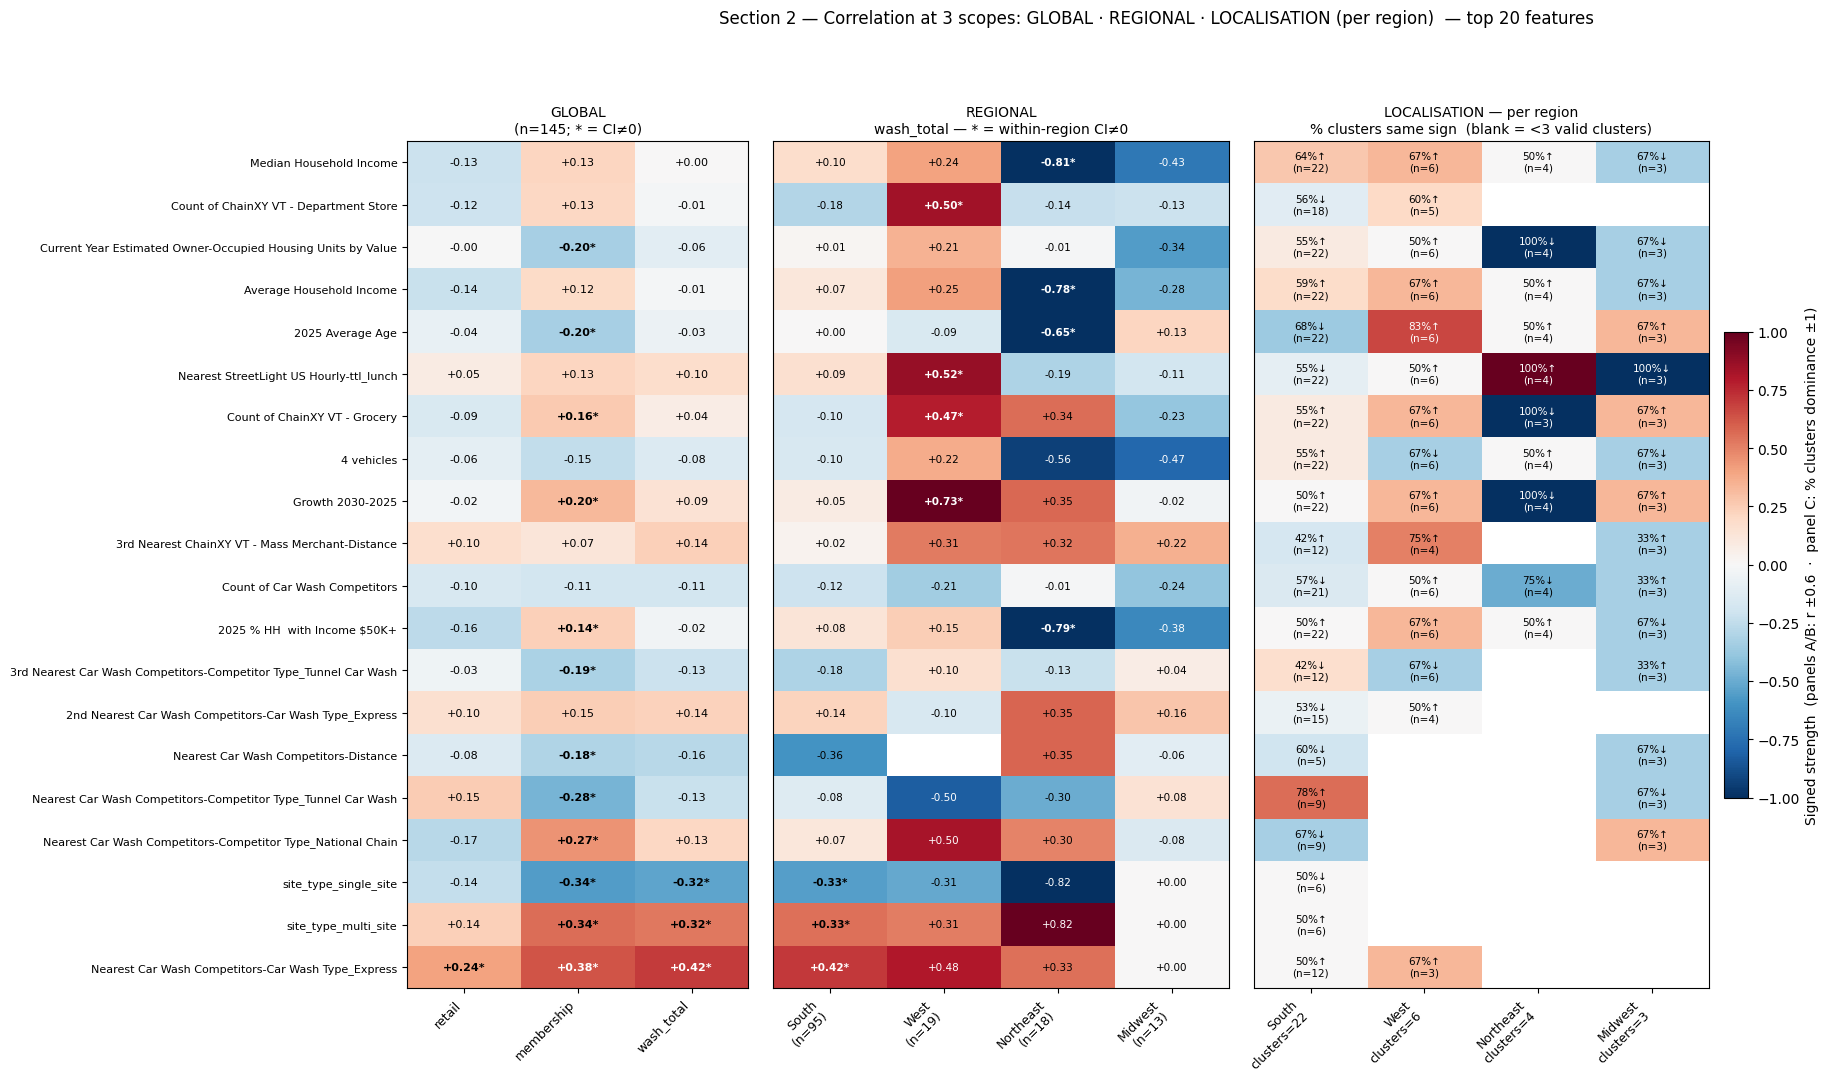

Features with regional signal AND aligned cluster majority (≥67% in same region):
  [Northeast:100%↓(n=4)]   Current Year Estimated Owner-Occupied Housing Units by Value
  [South:68%↓(n=22), West:83%↑(n=6)]   2025 Average Age
  [Northeast:100%↑(n=4), Midwest:100%↓(n=3)]   Nearest StreetLight US Hourly-ttl_lunch
  [Northeast:100%↓(n=3)]   Count of ChainXY VT - Grocery
  [Northeast:100%↓(n=4)]   Growth 2030-2025
  [West:75%↑(n=4)]   3rd Nearest ChainXY VT - Mass Merchant-Distance
  [Northeast:75%↓(n=4)]   Count of Car Wash Competitors
  [South:78%↑(n=9)]   Nearest Car Wash Competitors-Competitor Type_Tunnel Car Wash

Global × Regional cross-scope tally:
  [R]  Median Household Income
  [R]  Count of ChainXY VT - Department Store
  [G·L(Northeast)]  Current Year Estimated Owner-Occupied Housing Units by Value
  [R]  Average Household Income
  [G·R·L(South,West)]  2025 Average Age
  [R·L(Northeast,Midwest)]  Nearest StreetLight US Hourly-ttl_lunch
  [G·R·L(Northeast)]  Count of ChainXY VT 

In [4]:
# ---- 0. Global Spearman r per feature × target ----
sp = pd.DataFrame({
    t: [spearmanr(X[c], targets[t]).statistic if X[c].std() > 0 else np.nan for c in X.columns]
    for t in targets.columns
}, index=X.columns)

TOP_N = 20
top = sp.abs().mean(axis=1).sort_values(ascending=False).head(TOP_N).index[::-1].tolist()

# ---- 1. Bootstrap CI helper ----
def bs_ci(x, y, n_boot=500, rng=None):
    rng = rng or np.random.default_rng(RANDOM_STATE)
    n = len(x); rs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        rs[i] = spearmanr(x[idx], y[idx]).statistic
    return np.percentile(rs, [2.5, 97.5])

global_ci_sig = {}
for t in targets.columns:
    yv = targets[t].values
    for f in top:
        lo, hi = bs_ci(X[f].values, yv)
        global_ci_sig[(f, t)] = (lo * hi) > 0

# ---- 2. PER REGION raw Spearman r (wash_total) ----
regions = ['South','West','Northeast','Midwest']
region_n = {r: int((region_col == r).sum()) for r in regions}
y_wt = targets['wash_total']
region_corr   = pd.DataFrame(index=top, columns=regions, dtype=float)
region_ci_sig = {}
for r in regions:
    m = (region_col == r).values
    yk = y_wt.values[m]
    for f in top:
        xk = X[f].values[m]
        if np.std(xk) == 0 or np.std(yk) == 0:
            region_corr.loc[f, r] = np.nan; region_ci_sig[(f, r)] = False; continue
        region_corr.loc[f, r] = spearmanr(xk, yk).statistic
        lo, hi = bs_ci(xk, yk, n_boot=300)
        region_ci_sig[(f, r)] = (lo * hi) > 0

# ---- 3. Per-cluster r for all 35 clusters, then aggregate PER REGION ----
clusters_all = sorted(loc_col.unique())
per_cluster = pd.DataFrame(index=top, columns=clusters_all, dtype=float)
for k in clusters_all:
    m = (loc_col == k).values
    yk = y_wt.values[m]
    if np.std(yk) == 0: continue
    for f in top:
        xk = X[f].values[m]
        if np.std(xk) == 0: continue
        per_cluster.loc[f, k] = spearmanr(xk, yk).statistic

cluster_to_region = df.groupby('localisation')['region'].agg(lambda s: s.mode().iloc[0]).to_dict()
region_clusters = {r: [k for k in clusters_all if cluster_to_region[k] == r] for r in regions}
n_clusters_per_region = {r: len(region_clusters[r]) for r in regions}

MIN_VALID = 3  # require ≥3 valid clusters in a region to show the cell
cons_score  = pd.DataFrame(index=top, columns=regions, dtype=float)
cons_sign   = pd.DataFrame(index=top, columns=regions, dtype=object)
cons_n      = pd.DataFrame(index=top, columns=regions, dtype=float)
cons_signed = pd.DataFrame(index=top, columns=regions, dtype=float)

for r in regions:
    cks = region_clusters[r]
    for f in top:
        vals = per_cluster.loc[f, cks].dropna().values
        nn = len(vals)
        cons_n.loc[f, r] = nn
        if nn < MIN_VALID:
            cons_score.loc[f, r] = np.nan
            cons_sign.loc[f, r]  = 'na'
            cons_signed.loc[f, r] = np.nan
            continue
        pos = int((vals > 0).sum()); neg = int((vals < 0).sum())
        dom_count = max(pos, neg)
        dom_sign  = 'pos' if pos >= neg else 'neg'
        pct = dom_count / nn
        cons_score.loc[f, r] = pct
        cons_sign.loc[f, r]  = dom_sign
        mag = (pct - 0.5) * 2
        cons_signed.loc[f, r] = mag if dom_sign == 'pos' else -mag

# ---- Plot: 3 panels (all heatmaps) ----
fig = plt.figure(figsize=(20, max(9, 0.45 * TOP_N + 2)))
gs = fig.add_gridspec(1, 3, width_ratios=[1.5, 2.0, 2.0], wspace=0.06)

def draw_heatmap(ax, mat, col_labels, row_labels, title, annotate_fn, vmin=-0.6, vmax=0.6):
    ax.imshow(mat, cmap='RdBu_r', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, fontsize=9, rotation=45, ha='right')
    if row_labels is not None:
        ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels, fontsize=8)
    else:
        ax.set_yticks([])
    for (i, j), v in np.ndenumerate(mat):
        if np.isnan(v): continue
        annotate_fn(ax, i, j, v, vmax)
    ax.set_title(title, fontsize=10)

# A: GLOBAL heatmap
ax_a = fig.add_subplot(gs[0])
matA = sp.loc[top, ['retail','membership','wash_total']].values.astype(float)
def annotate_global(ax, i, j, v, vmax):
    f = top[i]; t = ['retail','membership','wash_total'][j]
    sig = global_ci_sig.get((f, t), False)
    label = f'{v:+.2f}' + ('*' if sig else '')
    ax.text(j, i, label, ha='center', va='center', fontsize=8,
            color='white' if abs(v) > vmax * 0.6 else 'black',
            fontweight='bold' if sig else 'normal')
draw_heatmap(
    ax_a, matA,
    col_labels=['retail','membership','wash_total'],
    row_labels=top,
    title=f'GLOBAL\n(n=145; * = CI≠0)',
    annotate_fn=annotate_global,
)

# B: REGIONAL heatmap
ax_b = fig.add_subplot(gs[1])
matB = region_corr.values.astype(float)
def annotate_region(ax, i, j, v, vmax):
    f = top[i]; r = regions[j]
    sig = region_ci_sig.get((f, r), False)
    label = f'{v:+.2f}' + ('*' if sig else '')
    ax.text(j, i, label, ha='center', va='center', fontsize=7.5,
            color='white' if abs(v) > vmax * 0.6 else 'black',
            fontweight='bold' if sig else 'normal')
draw_heatmap(
    ax_b, matB,
    col_labels=[f'{r}\n(n={region_n[r]})' for r in regions],
    row_labels=None,
    title='REGIONAL\nwash_total — * = within-region CI≠0',
    annotate_fn=annotate_region,
)

# C: LOCALISATION — per region
ax_c = fig.add_subplot(gs[2])
matC = cons_signed.values.astype(float)
def annotate_local(ax, i, j, v, vmax):
    pct = cons_score.iloc[i, j]
    nn  = int(cons_n.iloc[i, j])
    sign = cons_sign.iloc[i, j]
    if np.isnan(pct):
        return
    arrow = '↑' if sign == 'pos' else '↓'
    label = f'{pct:.0%}{arrow}\n(n={nn})'
    ax.text(j, i, label, ha='center', va='center', fontsize=7.5,
            color='white' if abs(v) > 0.6 else 'black')
draw_heatmap(
    ax_c, matC,
    col_labels=[f'{r}\nclusters={n_clusters_per_region[r]}' for r in regions],
    row_labels=None,
    title='LOCALISATION — per region\n% clusters same sign  (blank = <3 valid clusters)',
    annotate_fn=annotate_local,
    vmin=-1, vmax=1,
)

sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=-1, vmax=1))
fig.colorbar(sm, ax=fig.axes, shrink=0.55, pad=0.01,
             label='Signed strength  (panels A/B: r ±0.6  ·  panel C: % clusters dominance ±1)')

fig.suptitle(f'Section 2 — Correlation at 3 scopes: GLOBAL · REGIONAL · LOCALISATION (per region)  — top {TOP_N} features',
             fontsize=12, y=1.00)
plt.show()

# ---- Cross-scope summary ----
def has_global_sig(f): return any(global_ci_sig.get((f, t), False) for t in targets.columns)
def has_region_sig(f): return any(region_ci_sig.get((f, r), False) for r in regions)
def region_with_strong_clusters(f, threshold=0.67):
    out = []
    for r in regions:
        pct = cons_score.loc[f, r]
        if not np.isnan(pct) and pct >= threshold:
            out.append((r, cons_sign.loc[f, r], cons_score.loc[f, r], int(cons_n.loc[f, r])))
    return out

print('Features with regional signal AND aligned cluster majority (≥67% in same region):')
hits = []
for f in top:
    strong = region_with_strong_clusters(f)
    if strong:
        details = ', '.join(f'{r}:{p:.0%}{"↑" if s=="pos" else "↓"}(n={n})' for r, s, p, n in strong)
        hits.append((f, details))
if hits:
    for f, details in hits:
        print(f'  [{details}]   {f}')
else:
    print('  (none)')

print('\nGlobal × Regional cross-scope tally:')
for f in top:
    flags = []
    if has_global_sig(f):  flags.append('G')
    if has_region_sig(f):  flags.append('R')
    strong = region_with_strong_clusters(f)
    if strong: flags.append('L(' + ','.join(r for r, _, _, _ in strong) + ')')
    if flags:
        print(f'  [{ "·".join(flags) }]  {f}')

## 3. SHAP feature importance — global · regional

Univariate correlations in Section 2 miss interactions and non-linear effects. **SHAP** (Shapley Additive Explanations) gives a multivariate, model-aware view: for each prediction, how much did each feature push it up or down? Aggregating across sites produces per-feature importance that handles correlated features better than permutation importance.

Four panels, top 15 features (ranked by global wash_total SHAP):

- **Panels A–C** — global SHAP for each target (retail, membership, wash_total) from a RandomForest fit on all 145 sites. Bar length = mean |SHAP value|. **Bar color = direction**: blue = feature value going up → prediction goes up; red = feature value up → prediction down.
- **Panel D** — regional SHAP heatmap for wash_total: fit a separate RF per region, normalize each region's top SHAP feature to 100%. Color encodes signed importance (blue/red = direction). Tells you which features matter most *within each region*.

**Caveat:** West (n=19), Northeast (n=18), Midwest (n=13) — small sample sizes give noisy SHAP rankings. Treat the South column (n=95) as most reliable; the others as suggestive.

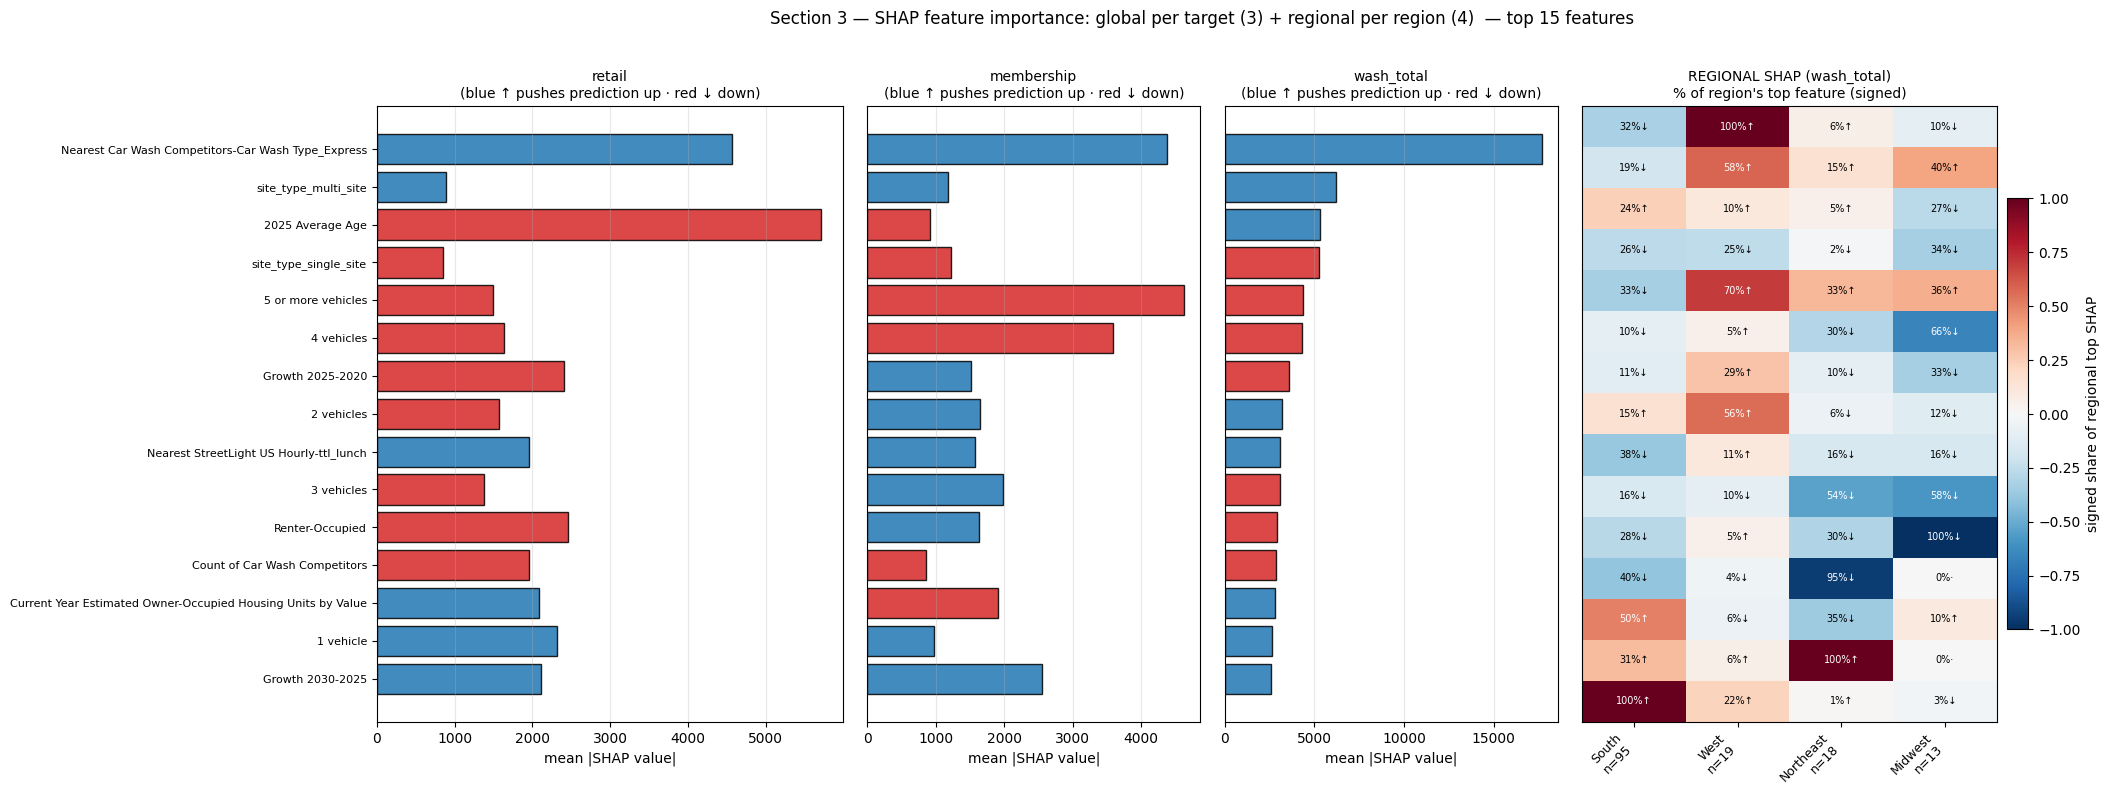

Top 10 SHAP features for wash_total (global):
  ↑    17699.5  Nearest Car Wash Competitors-Car Wash Type_Express
  ↑     6231.0  site_type_multi_site
  ↑     5313.7  2025 Average Age
  ↓     5279.2  site_type_single_site
  ↓     4355.2  5 or more vehicles
  ↓     4319.1  4 vehicles
  ↓     3591.3  Growth 2025-2020
  ↑     3198.9  2 vehicles
  ↑     3102.3  Nearest StreetLight US Hourly-ttl_lunch
  ↓     3098.5  3 vehicles

Features in top-15 SHAP for ALL three global targets:
  - Current Year Estimated Owner-Occupied Housing Units by Value
  - Growth 2030-2025
  - Nearest Car Wash Competitors-Car Wash Type_Express

Features appearing in top-5 SHAP for South region (n=95, most reliable):
  ↑    13041.9  Nearest Car Wash Competitors-Car Wash Type_Express
  ↑     6584.6  2025 Average Age
  ↓     5329.8  Count of ChainXY VT - Mass Merchant
  ↓     5155.1  site_type_single_site
  ↓     4925.1  Growth 2025-2020


In [5]:
def shap_direction(X_col_vals, shap_col_vals):
    """Spearman corr between feature value and its SHAP value.
       +1 = higher feature value → higher prediction; -1 = higher value → lower prediction."""
    if np.std(X_col_vals) == 0 or np.std(shap_col_vals) == 0:
        return 0
    r = spearmanr(X_col_vals, shap_col_vals).statistic
    return r if not np.isnan(r) else 0

def fit_shap(X_data, y_data):
    rf = RandomForestRegressor(n_estimators=400, max_features='sqrt', min_samples_leaf=2,
                               random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_data, y_data)
    expl = shap.TreeExplainer(rf)
    sv = expl.shap_values(X_data, check_additivity=False)
    mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=X_data.columns)
    dirn = pd.Series(
        [shap_direction(X_data.iloc[:, i].values, sv[:, i]) for i in range(X_data.shape[1])],
        index=X_data.columns,
    )
    return mean_abs, np.sign(dirn).astype(int)

# ---- Global SHAP (one RF per target) ----
shap_imp  = {}
shap_sign = {}
for name in ['retail', 'membership', 'wash_total']:
    imp, sign = fit_shap(X, targets[name])
    shap_imp[name]  = imp
    shap_sign[name] = sign

# ---- Regional SHAP (wash_total, one RF per region) ----
regional_shap_imp  = pd.DataFrame(index=X.columns, columns=regions, dtype=float)
regional_shap_sign = pd.DataFrame(index=X.columns, columns=regions, dtype=int)
for r in regions:
    m = (region_col == r).values
    Xr = X[m]
    yr = targets['wash_total'][m]
    imp, sign = fit_shap(Xr, yr)
    regional_shap_imp[r]  = imp
    regional_shap_sign[r] = sign

# ---- Top features (ranked by global wash_total SHAP) ----
TOP_N = 15
top_shap = shap_imp['wash_total'].sort_values(ascending=False).head(TOP_N).index[::-1].tolist()

# ---- Plot: 4 panels (3 target bars + 1 regional heatmap) ----
fig = plt.figure(figsize=(22, max(8, 0.4 * TOP_N + 1)))
gs = fig.add_gridspec(1, 4, width_ratios=[1.4, 1.0, 1.0, 1.5], wspace=0.06)

target_colors = {'retail':'#1f77b4', 'membership':'#ff7f0e', 'wash_total':'#2ca02c'}

for col, name in enumerate(['retail', 'membership', 'wash_total']):
    ax = fig.add_subplot(gs[col])
    imp = shap_imp[name].loc[top_shap].values
    sign = shap_sign[name].loc[top_shap].values
    bar_colors = ['#1f77b4' if s > 0 else '#d62728' if s < 0 else '#999999' for s in sign]
    ax.barh(range(len(top_shap)), imp, color=bar_colors, alpha=0.85, edgecolor='black')
    if col == 0:
        ax.set_yticks(range(len(top_shap)))
        ax.set_yticklabels(top_shap, fontsize=8)
    else:
        ax.set_yticks([])
    ax.set_xlabel('mean |SHAP value|')
    ax.set_title(f'{name}\n(blue ↑ pushes prediction up · red ↓ down)', fontsize=10)
    ax.grid(axis='x', alpha=0.3)

# Panel D: regional SHAP heatmap (wash_total)
ax = fig.add_subplot(gs[3])
reg_imp_norm = regional_shap_imp.loc[top_shap].copy()
for r in regions:
    mx = reg_imp_norm[r].max()
    if mx and not np.isnan(mx) and mx > 0:
        reg_imp_norm[r] = reg_imp_norm[r] / mx
reg_signed = reg_imp_norm * regional_shap_sign.loc[top_shap]
mat = reg_signed.values.astype(float)

ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(4))
ax.set_xticklabels([f'{r}\nn={region_n[r]}' for r in regions], fontsize=9, rotation=45, ha='right')
ax.set_yticks([])
for (i, j), v in np.ndenumerate(mat):
    if np.isnan(v): continue
    pct = abs(v) * 100
    arrow = '↑' if v > 0 else ('↓' if v < 0 else '·')
    ax.text(j, i, f'{pct:.0f}%{arrow}', ha='center', va='center', fontsize=7,
            color='white' if abs(v) > 0.5 else 'black')
ax.set_title('REGIONAL SHAP (wash_total)\n% of region\'s top feature (signed)', fontsize=10)

sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=-1, vmax=1))
fig.colorbar(sm, ax=ax, shrink=0.7, pad=0.02, label='signed share of regional top SHAP')

fig.suptitle(f'Section 3 — SHAP feature importance: global per target (3) + regional per region (4)  — top {TOP_N} features',
             fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

# ---- Summary ----
print('Top 10 SHAP features for wash_total (global):')
for f, v in shap_imp['wash_total'].sort_values(ascending=False).head(10).items():
    s = shap_sign['wash_total'].loc[f]
    arrow = '↑' if s > 0 else ('↓' if s < 0 else '·')
    print(f'  {arrow} {v:>10.1f}  {f}')

print('\nFeatures in top-15 SHAP for ALL three global targets:')
shared = set(shap_imp['retail'].sort_values(ascending=False).head(15).index) & \
         set(shap_imp['membership'].sort_values(ascending=False).head(15).index) & \
         set(shap_imp['wash_total'].sort_values(ascending=False).head(15).index)
for f in sorted(shared): print(f'  - {f}')

print('\nFeatures appearing in top-5 SHAP for South region (n=95, most reliable):')
top5_south = regional_shap_imp['South'].sort_values(ascending=False).head(5).index.tolist()
for f in top5_south:
    s = regional_shap_sign.loc[f, 'South']
    arrow = '↑' if s > 0 else '↓'
    val = regional_shap_imp.loc[f, 'South']
    print(f'  {arrow} {val:>10.1f}  {f}')